In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv("Netflix TV Shows and Movies.csv")

In [4]:
df.head()

,index,id,title,type,description,release_year,age_certification,runtime,imdb_id,imdb_score,imdb_votes
0,0,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,113,tt0075314,8.3,795222.0
1,1,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,tt0071853,8.2,530877.0
2,2,tm70993,Life of Brian,MOVIE,"Brian Cohen is an average young Jewish man, bu...",1979,R,94,tt0079470,8.0,392419.0
3,3,tm190788,The Exorcist,MOVIE,12-year-old Regan MacNeil begins to adapt an e...,1973,R,133,tt0070047,8.1,391942.0
4,4,ts22164,Monty Python's Flying Circus,SHOW,A British sketch comedy series with the shows ...,1969,TV-14,30,tt0063929,8.8,72895.0


In [5]:
df.info

<bound method DataFrame.info of       index         id                               title   type  \
0         0    tm84618                         Taxi Driver  MOVIE   
1         1   tm127384     Monty Python and the Holy Grail  MOVIE   
2         2    tm70993                       Life of Brian  MOVIE   
3         3   tm190788                        The Exorcist  MOVIE   
4         4    ts22164        Monty Python's Flying Circus   SHOW   
...     ...        ...                                 ...    ...   
5278   5278  tm1040816         Momshies! Your Soul is Mine  MOVIE   
5279   5279  tm1014599                           Fine Wine  MOVIE   
5280   5280  tm1045018                               Clash  MOVIE   
5281   5281  tm1098060                      Shadow Parties  MOVIE   
5282   5282   ts271048  Mighty Little Bheem: Kite Festival   SHOW   

                                            description  release_year  \
0     A mentally unstable Vietnam War veteran works ...          1

In [6]:
df.shape

(5283, 11)

In [10]:
df.isnull().sum()

index                   0
id                      0
title                   0
type                    0
description             5
release_year            0
age_certification    2285
runtime                 0
imdb_id                 0
imdb_score              0
imdb_votes             16
dtype: int64

In [9]:
df.isnull().sum()/(df.shape[0]*df.shape[1])*100

index                0.000000
id                   0.000000
title                0.000000
type                 0.000000
description          0.008604
release_year         0.000000
age_certification    3.931995
runtime              0.000000
imdb_id              0.000000
imdb_score           0.000000
imdb_votes           0.027533
dtype: float64

In [12]:
df["age_certification"].unique()

<StringArray>
[    'R',    'PG', 'TV-14',     'G', 'PG-13',     nan, 'TV-MA', 'TV-PG',
  'TV-Y',  'TV-G', 'TV-Y7', 'NC-17']
Length: 12, dtype: str

In [92]:
df["type"].unique()

<StringArray>
['MOVIE', 'SHOW']
Length: 2, dtype: str

In [84]:
df_model = df[["release_year","type","age_certification","runtime","imdb_votes","imdb_score"]]

In [85]:
df_model.head()

,release_year,type,age_certification,runtime,imdb_votes,imdb_score
0,1976,MOVIE,R,113,795222.0,8.3
1,1975,MOVIE,PG,91,530877.0,8.2
2,1979,MOVIE,R,94,392419.0,8.0
3,1973,MOVIE,R,133,391942.0,8.1
4,1969,SHOW,TV-14,30,72895.0,8.8


In [86]:
df_model.isnull().sum()

release_year            0
type                    0
age_certification    2285
runtime                 0
imdb_votes             16
imdb_score              0
dtype: int64

Replacing null values with mode value or unknown

In [87]:
df_model["imdb_votes"]=df_model["imdb_votes"].fillna(df_model["imdb_votes"].mode()[0])

In [88]:
df_model['age_certification']=df_model['age_certification'].fillna("Unknown")

In [89]:
df_model.isnull().sum().sum()

np.int64(0)

Convert Categorical to Numerical using One Hot Encoding

In [90]:
df_model = pd.get_dummies(df_model, columns=['age_certification','type'], drop_first=True)

In [91]:
df_model.head()

,release_year,runtime,imdb_votes,imdb_score,age_certification_NC-17,age_certification_PG,age_certification_PG-13,age_certification_R,age_certification_TV-14,age_certification_TV-G,age_certification_TV-MA,age_certification_TV-PG,age_certification_TV-Y,age_certification_TV-Y7,age_certification_Unknown,type_SHOW
0,1976,113,795222.0,8.3,False,False,False,True,False,False,False,False,False,False,False,False
1,1975,91,530877.0,8.2,False,True,False,False,False,False,False,False,False,False,False,False
2,1979,94,392419.0,8.0,False,False,False,True,False,False,False,False,False,False,False,False
3,1973,133,391942.0,8.1,False,False,False,True,False,False,False,False,False,False,False,False
4,1969,30,72895.0,8.8,False,False,False,False,True,False,False,False,False,False,False,True


Defining dependent and independent variable

In [93]:
X= df_model.drop("imdb_score", axis=1)
Y=df_model["imdb_score"]

Feature Scaling to make Mean= 0, Standard deviation= 1

In [94]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train-Test Split & Model Building
Using 80% data to train and 20% data to test
----helps to check real performance

In [95]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled,   
    Y,          
    test_size=0.2, 
    random_state=42
)

In [96]:
print(X_train.shape)
print(X_test.shape)

(4226, 15)
(1057, 15)


Regression Model

imdb_score=a+b1∗(votes)+b2∗(runtime)+...

In [97]:
from sklearn.linear_model import LinearRegression

In [98]:
model = LinearRegression()

In [99]:
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [100]:
Y_pred = model.predict(X_test)

<function matplotlib.pyplot.show(close=None, block=None)>

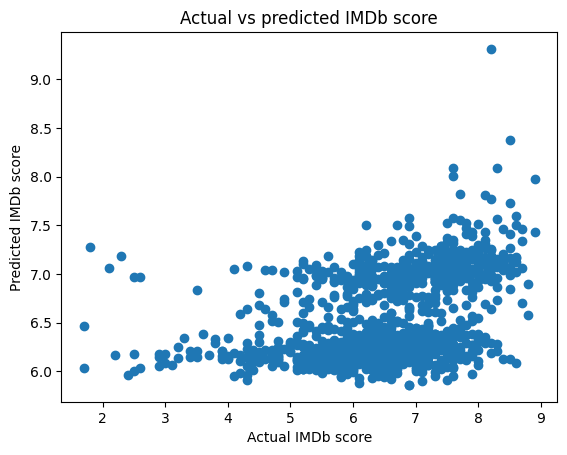

In [101]:
plt.scatter(Y_test,Y_pred)
plt.xlabel("Actual IMDb score")
plt.ylabel("Predicted IMDb score")
plt.title("Actual vs predicted IMDb score")
plt.show

Check Model Coefficients

In [102]:
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coefficients)

                           Coefficient
release_year                 -0.129183
runtime                       0.128630
imdb_votes                    0.196088
age_certification_NC-17       0.004815
age_certification_PG         -0.066708
age_certification_PG-13      -0.048929
age_certification_R          -0.095339
age_certification_TV-14       0.012945
age_certification_TV-G       -0.096673
age_certification_TV-MA      -0.035465
age_certification_TV-PG      -0.050993
age_certification_TV-Y       -0.068774
age_certification_TV-Y7      -0.034131
age_certification_Unknown    -0.093780
type_SHOW                     0.450084


Model Evaluation (MAE,MSE,RMSE,R2 Score)

In [105]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [106]:
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 0.8291959103471751
Mean Squared Error (MSE): 1.1997581556063623
Root Mean Squared Error (RMSE): 1.09533472308987
R2 Score: 0.15744440842466423


In [134]:
residuals = Y_test - Y_pred

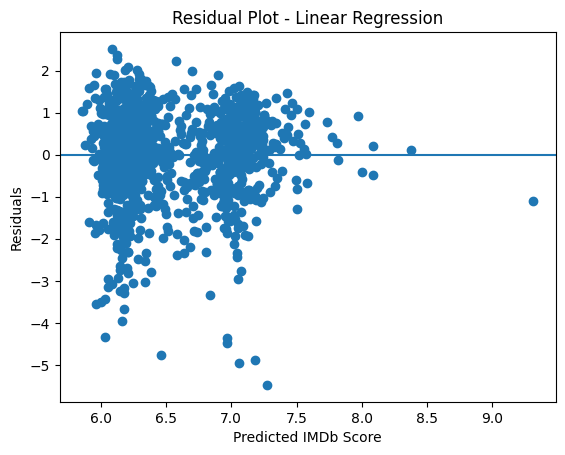

In [135]:
plt.scatter(Y_pred, residuals)
plt.xlabel("Predicted IMDb Score")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")
plt.axhline(y=0)
plt.show()

As the model is weak applying Random Forest Regressor

In [107]:
from sklearn.ensemble import RandomForestRegressor

In [108]:
rf_model = RandomForestRegressor(
    n_estimators=100,      # number of decision trees
    random_state=42
)

In [109]:
rf_model.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [110]:
Y_pred_rf = rf_model.predict(X_test)

In [111]:
mae_rf = mean_absolute_error(Y_test, Y_pred_rf)
mse_rf = mean_squared_error(Y_test, Y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(Y_test, Y_pred_rf)

print("Random Forest Results:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results:
MAE: 0.7960370860927153
RMSE: 1.0769763990390129
R2 Score: 0.18545097765661123


In [136]:
residuals_rf = Y_test - Y_pred_rf

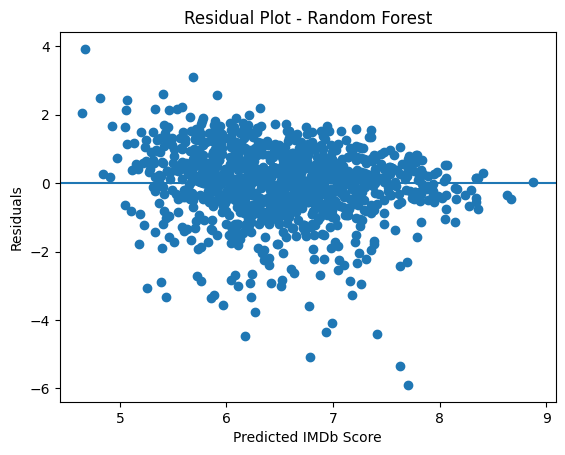

In [137]:
plt.scatter(Y_pred_rf, residuals_rf)
plt.xlabel("Predicted IMDb Score")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest")
plt.axhline(y=0)
plt.show()

As both models are weak... using Gradient Boosting Regressor model

In [264]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

gb_model = GradientBoostingRegressor(random_state=42)

gb_model.fit(X_train, Y_train)

Y_pred_gb = gb_model.predict(X_test)

In [265]:
mae_gb = mean_absolute_error(Y_test, Y_pred_gb)
mse_gb = mean_squared_error(Y_test, Y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(Y_test, Y_pred_gb)

print("Random Forest Results:")
print("MAE:", mae_gb)
print("RMSE:", rmse_gb)
print("R2 Score:", r2_gb)

Random Forest Results:
MAE: 0.7707363133394397
RMSE: 1.0380825076915516
R2 Score: 0.2432218224547602


Feature Importance

In [112]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

imdb_votes                   0.420365
runtime                      0.255497
release_year                 0.148903
type_SHOW                    0.093745
age_certification_Unknown    0.021054
age_certification_R          0.010115
age_certification_PG         0.008630
age_certification_PG-13      0.008017
age_certification_TV-MA      0.007404
age_certification_TV-G       0.006762
age_certification_TV-PG      0.006057
age_certification_TV-14      0.005927
age_certification_TV-Y7      0.003128
age_certification_TV-Y       0.002956
age_certification_NC-17      0.001438
dtype: float64


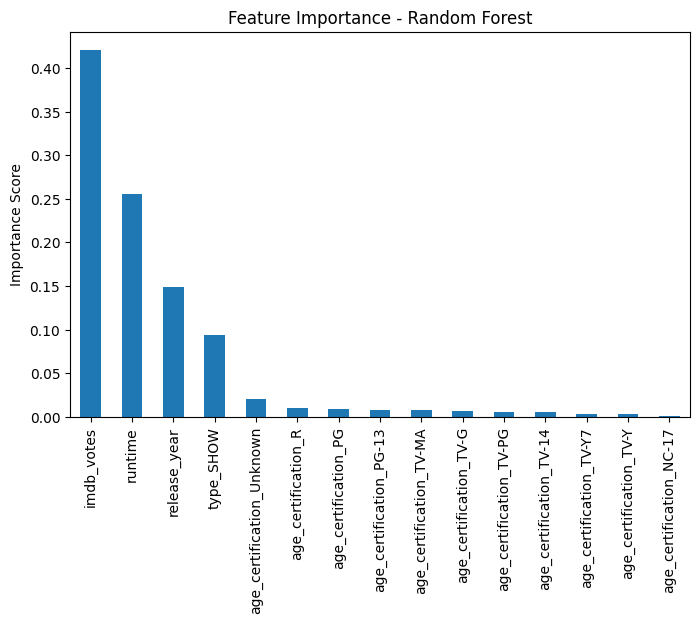

In [113]:
plt.figure(figsize=(8,5))
feature_importance.plot(kind='bar')
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance Score")
plt.show()

Predict Rating for a New Movie

In [122]:
print(X.columns)

Index(['release_year', 'runtime', 'imdb_votes', 'age_certification_NC-17',
       'age_certification_PG', 'age_certification_PG-13',
       'age_certification_R', 'age_certification_TV-14',
       'age_certification_TV-G', 'age_certification_TV-MA',
       'age_certification_TV-PG', 'age_certification_TV-Y',
       'age_certification_TV-Y7', 'age_certification_Unknown', 'type_SHOW'],
      dtype='str')


In [267]:
new_movie = {
    'imdb_votes': 3000,
    'runtime': 250,
    'release_year': 2022,
    'age_certification': 'TV-MA',
    'type': 'MOVIE'
}

In [268]:
new_movie_df = pd.DataFrame([new_movie])

In [269]:
new_movie_df = pd.get_dummies(new_movie_df, 
                              columns=['age_certification', 'type'],
                              drop_first=True)

In [270]:
new_movie_df = new_movie_df.reindex(columns=X.columns, fill_value=0)

In [271]:
new_movie_scaled = scaler.transform(new_movie_df)

In [272]:
predicted_rating = gb_model.predict(new_movie_scaled)

print("Predicted IMDb Rating:", round(predicted_rating[0],2))

Predicted IMDb Rating: 7.54
